This notebook recreates the graphs in Fig. 5 of the paper by Layden et al. See paper for context


In [2]:
# imports
import itertools
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import joblib

# imports from qemcmc
from qemcmc.model import EnergyModel
from qemcmc.utils import ModelMaker
from qemcmc.sampler import QeProposal
from qemcmc.coarse_grain import CoarseGraining


In [3]:

# Define parameters
n_spins = 8  # Number of spins in the system

# QeMCMC parameters
gamma = 0.45
time = 10

In [4]:
# Initialise a random fully connected Ising model
model  = ModelMaker(n_spins, "Fully Connected Ising", "example model").model

# Classically calculate some useful quantifies

In [5]:
# (Classically) calculate energies of all configurations
all_energies = model.get_all_energies()


# (Classically) calculate the energy differences for all pairs of configurations
# And the Hamming distances for all pairs of configurations
S = np.array([np.binary_repr(s, width=n_spins) for s in range(2**n_spins)])
S_integer_arr = np.array([[int(bit) for bit in state] for state in S])
E_s = np.array(all_energies)

# find matrices of Energy differences of the configyurations, and hamming distances
E_diffs = np.zeros((2**n_spins, 2**n_spins))
hamming_dists = np.zeros((2**n_spins, 2**n_spins))
for s in S:
    for s_prime in S:
        hamming_dist = np.sum(np.bitwise_xor(S_integer_arr[int(s, 2)], S_integer_arr[int(s_prime, 2)]))
        E_diff = abs(E_s[int(s, 2)] - E_s[int(s_prime, 2)])
        E_diffs[int(s, 2), int(s_prime, 2)] = E_diff
        hamming_dists[int(s, 2), int(s_prime, 2)] = hamming_dist




# Simulate classical proposals

Instead of using classical_mcmc, we quickly generate the proposal distruibutions manually

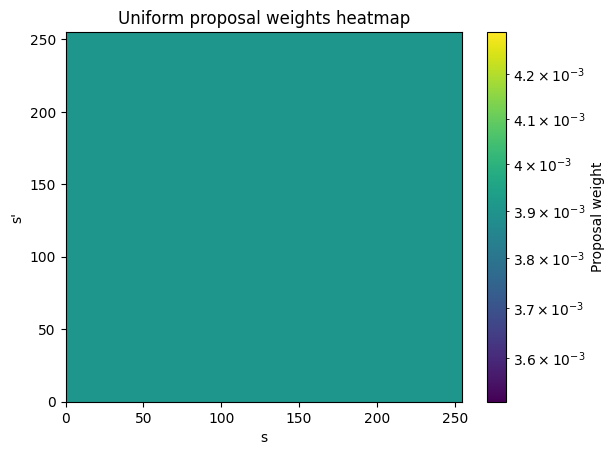

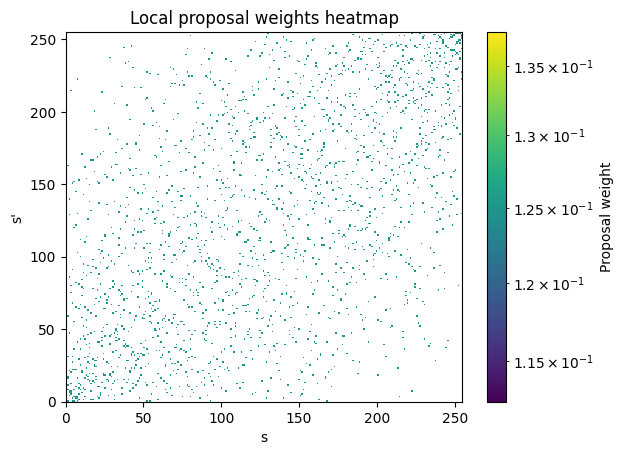

In [6]:
# Now calculate the proposal probabilities for the classical MMCMC proposals

# Uniform proposal probability is trivial
uniform_weights = np.ones_like(E_diffs)
row_sums = uniform_weights.sum(axis=1)
uniform_weights = uniform_weights / row_sums[:, np.newaxis]



# Local probability is also relatively simple
local_weights = np.zeros_like(E_diffs)
local_weights[np.isclose(hamming_dists, 1)] = 1

# normalise
row_sums = local_weights.sum(axis=1)
local_weights = local_weights / row_sums[:, np.newaxis]





# Plot the proposal probabilities as a heatmap, ordered by energy
E_order = np.argsort(E_s)
uniform_weights_ordered = uniform_weights[E_order, :][:, E_order]
# make the color graident logarithmic
plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=uniform_weights_ordered.flatten(), norm="log")
plt.title("Uniform proposal weights heatmap")
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()

local_weights_ordered = local_weights[E_order, :][:, E_order]
plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=local_weights_ordered.flatten(), norm="log")
plt.title("Local proposal weights heatmap") 
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()


The uniform proposal of course has a very uniform distribution, while the local proposal has a sparse and structured distribution. Note that the configurations are ordered (on both axis) by their energy.

# Quantum-enhanced proposals

Lets see how the quantum proposal distribution looks. To do this, we first take samples using the qe_proposal class.

  0%|          | 0/256 [00:00<?, ?it/s]

100%|██████████| 256/256 [01:27<00:00,  2.92it/s]


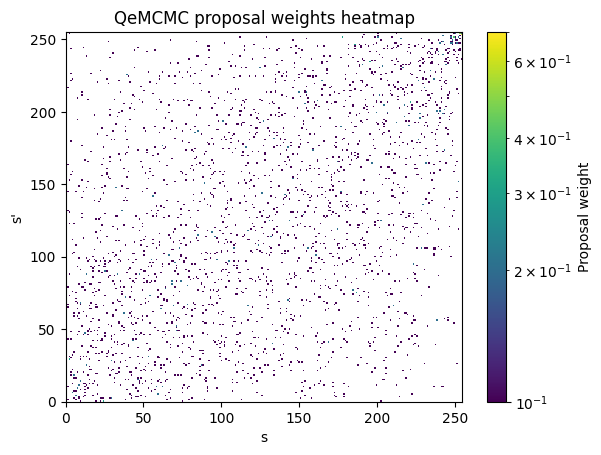

In [7]:
# How many times to sample each proposal
reps = 10

# brute force method to get QeMCMC weights
quantum_proposal = QeProposal(model, gamma=gamma, time=time)
qemcmc_weights_brute = np.zeros_like(E_diffs)
self_proposals = 0
for i, s in enumerate(tqdm.tqdm(S)):
    for j in range(reps):
        state = quantum_proposal.update(s)
        state_int = int(state, 2)
        qemcmc_weights_brute[i, state_int] += 1
qemcmc_weights_brute = qemcmc_weights_brute / (reps)

qemcmc_weights_brute_ordered = qemcmc_weights_brute[E_order, :][:, E_order]
# make the color graident logarithmic
plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=qemcmc_weights_brute_ordered.flatten(), norm="log")
plt.title("QeMCMC proposal weights heatmap")
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()


The distribution is very structured around the diagonal, suggesting proposals of small energy change are higher in probability. The graph is very sparse however, so lets extract exact statevectors so that we can better understand the proposal.

In [8]:
# This is now depreciated

# qemcmc_weights = np.zeros_like(E_diffs)
# for i, s in enumerate(tqdm.tqdm(S)):
#     probabilities = np.abs(quantum_proposal.CM.get_state_vector(s, gamma, time)) ** 2
#     qemcmc_weights[int(i),:] += probabilities


# qemcmc_weights_ordered = qemcmc_weights[E_order, :][:, E_order]


# plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=qemcmc_weights_ordered.flatten(), norm="log")
# plt.title("QeMCMC proposal weights heatmap")
# plt.xlabel("s")
# plt.ylabel("s'")
# plt.colorbar(label="Proposal weight")
# # plt.show()
# self_proposals_percent = (100 * np.sum(np.diag(qemcmc_weights))) / (reps * (2**n_spins))

# # normalise
# row_sums = qemcmc_weights.sum(axis=1)
# qemcmc_weights = qemcmc_weights / row_sums[:, np.newaxis]
# #qemcmc_weights[np.diag_indices_from(qemcmc_weights)] = 0
# print("self_proposals_percent:", self_proposals_percent)
# print("qemcmc_weights:", qemcmc_weights)


# Hamming weight plot

Plot cumulative hamming weight of each proposal to compare

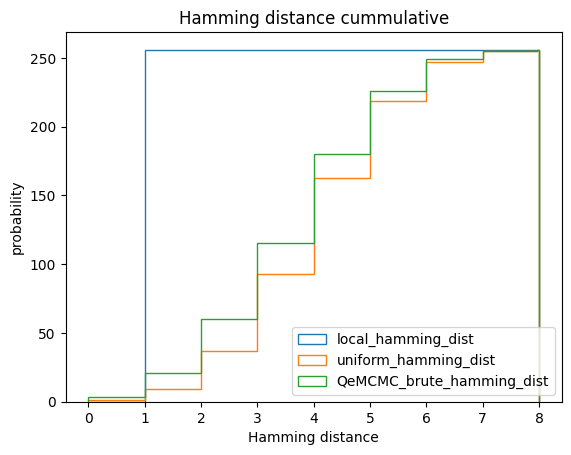

In [9]:


row_sums_brute = qemcmc_weights_brute.sum(axis=1)
qemcmc_weights_brute = qemcmc_weights_brute / row_sums_brute[:, np.newaxis]

# plot histograms of hamming distances
weights_list = [local_weights, uniform_weights, qemcmc_weights_brute]
labels = ["local", "uniform", "QeMCMC_brute"]
for weights, label in zip(weights_list, labels):
    plt.hist(hamming_dists.flatten(), bins=2**n_spins, weights=weights.flatten(), density=False, histtype="step", cumulative=True, label=label + "_hamming_dist")
    # plt.hist(E_diffs.flatten(), bins = n_spins, weights = weights.flatten(), density=True, histtype="step",
    #         cumulative=True, label=label+"_Energy_difference")
plt.legend()
plt.title("Hamming distance cummulative")
plt.xlabel("Hamming distance")
plt.ylabel("probability")
plt.show()



# Energy difference plot

Plot cumulative hamming weight of proposals

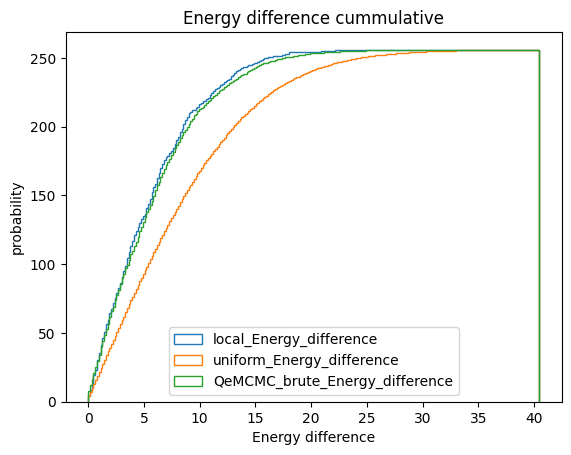

In [10]:


# plot energy difference histograms 
for weights, label in zip(weights_list, labels):
    plt.hist(E_diffs.flatten(), bins=2 ** (n_spins), weights=weights.flatten(), density=False, histtype="step", cumulative=True, label=label + "_Energy_difference")
plt.legend()
plt.title("Energy difference cummulative")
plt.xlabel("Energy difference")
plt.ylabel("probability")
plt.show()

# Bonus

Recreating the same graphs, but with coarse graining. This is a lot harder to do while "cheating" with the statevector approach, so instead we will just sample.



maximum qubits used: 4.0


100%|██████████| 256/256 [01:10<00:00,  3.65it/s]


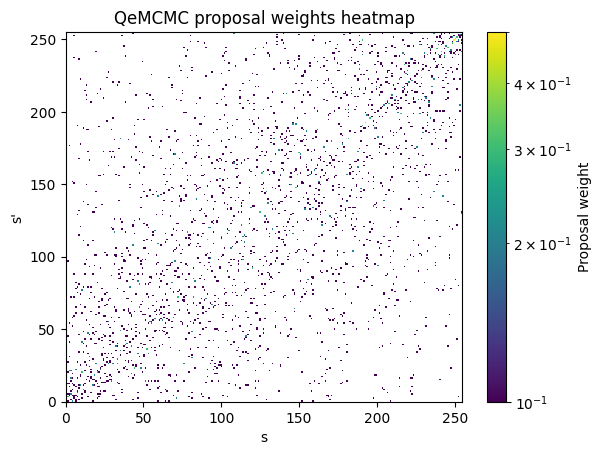

In [11]:
# How many times to sample each proposal
reps = 10

# 2 sub groups
m = 2
print("maximum qubits used:", np.ceil(n_spins / m))

# brute force method to get QeMCMC weights
quantum_proposal = QeProposal(model, gamma=gamma, time=time, m = m)
qemcmc_weights_brute_2 = np.zeros_like(E_diffs)
self_proposals = 0
for i, s in enumerate(tqdm.tqdm(S)):
    for j in range(reps):
        state = quantum_proposal.update(s)
        state_int = int(state, 2)
        qemcmc_weights_brute_2[i, state_int] += 1
qemcmc_weights_brute_2 = qemcmc_weights_brute_2 / (reps)

qemcmc_weights_brute_ordered_2 = qemcmc_weights_brute_2[E_order, :][:, E_order]
# make the color graident logarithmic
plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=qemcmc_weights_brute_ordered_2.flatten(), norm="log")
plt.title("QeMCMC proposal weights heatmap")
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()

maximum qubits used: 2.0


100%|██████████| 256/256 [01:32<00:00,  2.77it/s]


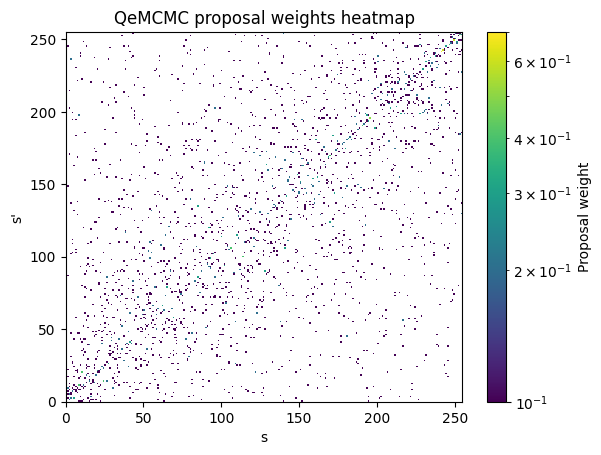

In [12]:
# How many times to sample each proposal
reps = 10

# 4 sub groups
m = 4
print("maximum qubits used:", np.ceil(n_spins / m))

# brute force method to get QeMCMC weights
quantum_proposal = QeProposal(model, gamma=gamma, time=time, m = m)
qemcmc_weights_brute_3 = np.zeros_like(E_diffs)
self_proposals = 0
for i, s in enumerate(tqdm.tqdm(S)):
    for j in range(reps):
        state = quantum_proposal.update(s)
        state_int = int(state, 2)
        qemcmc_weights_brute_3[i, state_int] += 1
qemcmc_weights_brute_3 = qemcmc_weights_brute_3 / (reps)

qemcmc_weights_brute_ordered_2 = qemcmc_weights_brute_3[E_order, :][:, E_order]
# make the color graident logarithmic
plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=qemcmc_weights_brute_ordered_2.flatten(), norm="log")
plt.title("QeMCMC proposal weights heatmap")
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()

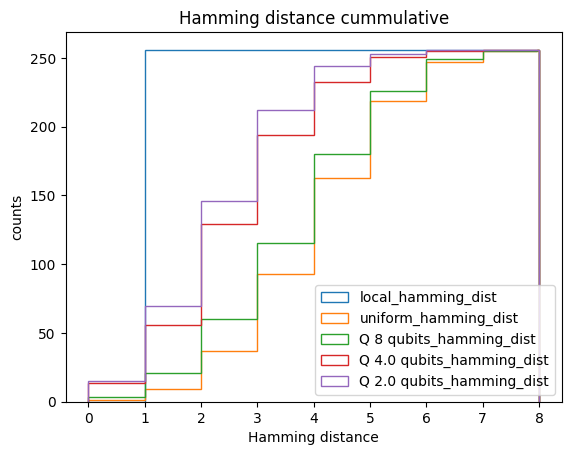

In [16]:
cg_weights_list = [local_weights, uniform_weights, qemcmc_weights_brute, qemcmc_weights_brute_2, qemcmc_weights_brute_3]
cg_labels = ["local", "uniform", f"Q {n_spins} qubits", f"Q {np.ceil(n_spins/2)} qubits", f"Q {np.ceil(n_spins/4)} qubits"]

for weights, label in zip(cg_weights_list, cg_labels):
    plt.hist(hamming_dists.flatten(), bins=2**n_spins, weights=weights.flatten(), density=False, histtype="step", cumulative=True, label=label + "_hamming_dist")
    # plt.hist(E_diffs.flatten(), bins = n_spins, weights = weights.flatten(), density=True, histtype="step",
    #         cumulative=True, label=label+"_Energy_difference")
plt.legend()
plt.title("Hamming distance cummulative")
plt.xlabel("Hamming distance")
plt.ylabel("counts")
plt.show()

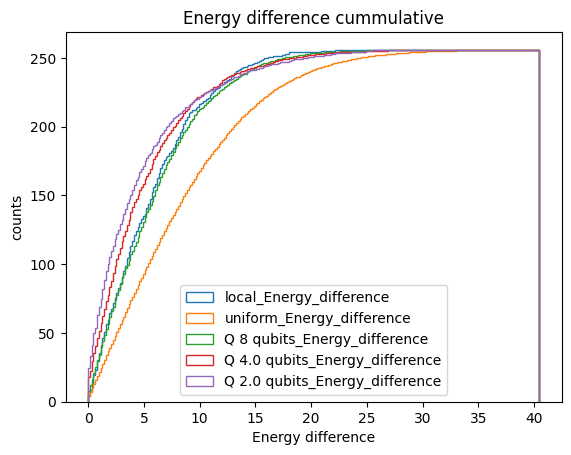

In [15]:



# plot energy difference histograms with area under curve for each method
for weights, label in zip(cg_weights_list, cg_labels):
    plt.hist(E_diffs.flatten(), bins=2 ** (n_spins), weights=weights.flatten(), density=False, histtype="step", cumulative=True, label=label + "_Energy_difference")
plt.legend()
plt.title("Energy difference cummulative")
plt.xlabel("Energy difference")
plt.ylabel("counts")
plt.show()